## Loading Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/sample_submission.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/all_data.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/test_public_expanded.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/test_private_expanded.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/toxicity_individual_annotations.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/train.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/identity_individual_annotations.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/test.csv


In [2]:
!pip install torch scikit-learn sentence-transformers -q

In [3]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc

device = "cuda" if torch.cuda.is_available() else "cpu"
display(f"device: {device}")

'device: cuda'

## Data prep

### Loading the Dataset

In [4]:
toxicity_train_path = "/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/train.csv"
temp_toxicity_train_df = pd.read_csv(toxicity_train_path, nrows=2, low_memory=True, memory_map=True)

In [5]:
mapdtype = {'int64': 'int32', 'float64':'float32'}
toxicity_dtypes = list(temp_toxicity_train_df.dtypes.apply(str).replace(mapdtype))
toxicity_dtypes = {key: value for (key, value) in enumerate(toxicity_dtypes)}

In [6]:
toxicity_train_df = pd.read_csv(toxicity_train_path, nrows=25000, low_memory=True, memory_map=True, dtype=toxicity_dtypes)
toxicity_valid_df = toxicity_train_df[:5000]
toxicity_train_df = toxicity_train_df[5001:]

### Dataset Info

In [7]:
toxicity_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 5001 to 24999
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   19999 non-null  int32  
 1   target                               19999 non-null  float32
 2   comment_text                         19999 non-null  object 
 3   severe_toxicity                      19999 non-null  float32
 4   obscene                              19999 non-null  float32
 5   identity_attack                      19999 non-null  float32
 6   insult                               19999 non-null  float32
 7   threat                               19999 non-null  float32
 8   asian                                4076 non-null   float32
 9   atheist                              4076 non-null   float32
 10  bisexual                             4076 non-null   float32
 11  black                    

In [8]:
toxicity_train_df.head()

,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
5001,247680,0.000000,The article suggests that the Boyles' support ...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,42723,approved,0,0,0,0,0,0.00000,0,4
5002,247681,0.000000,Interesting article,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,42708,approved,0,0,0,1,0,0.00000,0,4
5003,247684,0.200000,Gary. I do not think you can use numbers based...,0.000000,0.000000,0.000000,0.200000,0.200000,0.0,0.0,...,42684,approved,0,0,0,0,0,0.00000,10,5
5004,247685,0.940476,"Child rape is cool, if the right people do it.",0.195833,0.096429,0.070833,0.128571,0.254167,NaN,NaN,...,30349,rejected,0,0,0,0,0,0.90119,0,1680
5005,247686,0.000000,Mr. Forester suffers from the same biased-driv...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,42880,approved,0,0,0,1,0,0.00000,0,4


### Sentence Transformer

In [9]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### PyTorch Dataset

In [10]:
class ToxicityDataset(Dataset):
    """PyTorch Class for Toxicity Dataset"""
    def __init__(self, toxicity_df, embedding_model, train=True):
        """
        Args
            toxicity_df: The input DataFrame
            embedding_model: The SentenceTransformer model to be used for embeddings
        Returns
            PyTorch Dataset object
        """
        self.toxicity_df = toxicity_df
        self.embedding_model = embedding_model
        self.train = train

        if self.train:
            self.toxicity_df['toxic_label'] = np.where(self.toxicity_df['target'] >= 0.5, 1, 0)
            self.toxicity_df['click_label'] = np.random.randint(2, size=len(toxicity_df))

        comment_text = toxicity_train_df['comment_text'].tolist()
        self.comment_text_embd = embedding_model.encode(comment_text)

    def __len__(self):
        """Returns the length of the dataset"""
        return len(self.toxicity_df)
        
    def __getitem__(self, idx):
        """
        Args
            idx: index of the item to be retrived
        Returns
            embeddings, binary toxic label, binary click label at the idx
        """
        df_idx = self.toxicity_df.iloc[idx]
        
        if self.train:
            out = (self.comment_text_embd[idx], df_idx['toxic_label'], df_idx['click_label'])
        else: 
            out = (self.comment_text_embd[idx])
            
        return out

In [11]:
toxicity_train_dataset = ToxicityDataset(toxicity_train_df, embedding_model)
toxicity_valid_dataset = ToxicityDataset(toxicity_valid_df, embedding_model)

In [12]:
toxicity_train_dataloader = DataLoader(toxicity_train_dataset, batch_size=32, num_workers=4, pin_memory=True)
toxicity_valid_dataloader = DataLoader(toxicity_valid_dataset, batch_size=32, num_workers=4, pin_memory=True)

## Model

### Building the model

In [13]:
class SharedBottomMLT(nn.Module):
    def __init__(self):
        super(SharedBottomMLT, self).__init__()
        # The Shared Bottom (Input 384 -> Output 128)
        self.shared = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU()
        )

        # 2. Task Head A: Engagement (Input 128 -> Output 1)
        self.engagement_head = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # 2. Task Head B: Toxicity (Input 128 -> Output 1)
        self.toxicity_head = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x1 = self.shared(x)

        engagement_x1 = self.engagement_head(x1)
        toxicity_x1 = self.toxicity_head(x1)

        return engagement_x1, toxicity_x1

### Model Traning

In [14]:
shared_bottom_model = SharedBottomMLT()
shared_bottom_model.to(device)
criterion = [nn.BCELoss(), nn.BCELoss()]
lr = 0.0001
total_loss, engagement_loss, toxicity_loss = 0, 0, 0
optimizer = torch.optim.SGD(shared_bottom_model.parameters(), lr=lr)

In [41]:
def train_one_epoch(model, train_dataloader, print_every=25):
    running_loss = 0.
    last_loss = 0.
    
    for i, data in enumerate(train_dataloader):
        inputs, toxicity_label, engagement_label = data
        inputs, toxicity_label, engagement_label = inputs.to(device), toxicity_label.to(device), engagement_label.to(device)
        
        optimizer.zero_grad()
        
        eng_out, tox_out = model(inputs)
    
        engagement_loss = criterion[0](eng_out.view(-1), engagement_label.float())
        toxicity_loss = criterion[1](tox_out.view(-1), toxicity_label.float())
    
        total_loss = engagement_loss + toxicity_loss
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        
        if (i+1) % print_every == 0:
            last_loss = running_loss/print_every
            print(f"Batch {i+1}: Loss = {last_loss:.4f}")
            running_loss = 0.0

    return last_loss

In [42]:
# train_one_epoch(shared_bottom_model, toxicity_train_dataloader)

In [43]:
def plot_curves(eng_labels, eng_preds, tox_labels, tox_preds):
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(eng_labels, eng_preds)
    eng_roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {eng_roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess baseline
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Engagement Head (ROC Curve)')
    plt.legend(loc="lower right")

    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(tox_labels, tox_preds)
    tox_pr_auc = auc(recall, precision)
    
    # Calculate the baseline for PR (ratio of positive class)
    pr_baseline = sum(tox_labels) / len(tox_labels)
    
    plt.plot(recall, precision, color='crimson', lw=2, label=f'PR curve (AUC = {tox_pr_auc:.3f})')
    plt.plot([0, 1], [pr_baseline, pr_baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({pr_baseline:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Toxicity Head (Precision-Recall Curve)')
    plt.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

In [44]:
def evaluate(model, valid_dataloader):
    model.eval()
    running_loss = 0.

    all_eng_preds, all_eng_labels = [], []
    all_tox_preds, all_tox_labels = [], []
    
    for i, data in enumerate(valid_dataloader):
        inputs, toxicity_label, engagement_label = data
        inputs, toxicity_label, engagement_label = inputs.to(device), toxicity_label.to(device), engagement_label.to(device)
        
        eng_out, tox_out = model(inputs)
    
        engagement_loss = criterion[0](eng_out.view(-1), engagement_label.float())
        toxicity_loss = criterion[1](tox_out.view(-1), toxicity_label.float())

        all_eng_preds.extend(eng_out.detach().cpu().numpy().flatten())
        all_eng_labels.extend(engagement_label.detach().cpu().numpy().flatten())
        all_tox_preds.extend(tox_out.detach().cpu().numpy().flatten())
        all_tox_labels.extend(toxicity_label.detach().cpu().numpy().flatten())
    
        total_loss = engagement_loss + toxicity_loss
        running_loss += total_loss.item()

    ## Convert pred-sigmoid vals to binary predictions
    eng_hard_preds = (np.array(all_eng_preds) >= 0.5).astype(int)
    tox_hard_preds = (np.array(all_tox_preds) >= 0.5).astype(int)

    ## Getting Accuracy, ROC-AUC scores
    eng_acc = accuracy_score(all_eng_labels, eng_hard_preds)
    eng_roc = roc_auc_score(all_eng_labels, eng_hard_preds)

    tox_acc = accuracy_score(all_tox_labels, tox_hard_preds)
    tox_roc = roc_auc_score(all_tox_labels, tox_hard_preds)
    tox_pr_auc = average_precision_score(all_tox_labels, tox_hard_preds)

    print("\\n--- Validation Metrics ---")
    print(f"Engagement -> Accuracy: {eng_acc:.4f} | ROC-AUC: {eng_roc:.4f}")
    print(f"Toxicity   -> Accuracy: {tox_acc:.4f} | ROC-AUC: {tox_roc:.4f} | PR-AUC: {tox_pr_auc:.4f}\\n")

    plot_curves(all_eng_labels, all_eng_preds, all_tox_labels, all_tox_preds)
    
    return running_loss/len(valid_dataloader)

In [45]:
def train(model, train_dataloader, valid_dataloader, num_epochs=5):
    model.train()
    best_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        train_loss = train_one_epoch(model, train_dataloader, print_every=125)
        valid_loss = evaluate(model, valid_dataloader)

        print(f"Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")
        if valid_loss < best_loss:
            best_loss = valid_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("Saved best model")

Epoch 1/5
Batch 125: Loss = 1.2116
Batch 250: Loss = 1.2067
Batch 375: Loss = 1.2048
Batch 500: Loss = 1.2082
Batch 625: Loss = 1.2054
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.4866 | ROC-AUC: 0.4998
Toxicity   -> Accuracy: 0.9546 | ROC-AUC: 0.5000 | PR-AUC: 0.0454\n


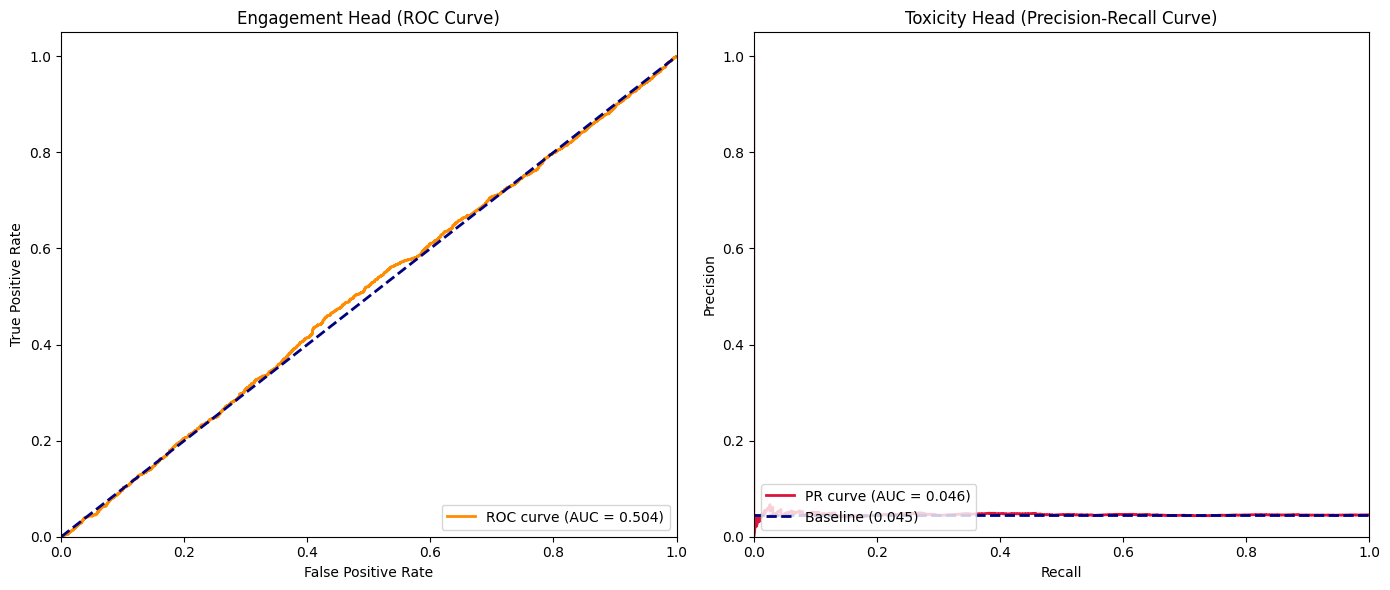

Train Loss: 1.2054, Valid Loss: 1.1932
Saved best model
Epoch 2/5
Batch 125: Loss = 1.2036
Batch 250: Loss = 1.1986
Batch 375: Loss = 1.1967
Batch 500: Loss = 1.2004
Batch 625: Loss = 1.1976
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.4870 | ROC-AUC: 0.5002
Toxicity   -> Accuracy: 0.9546 | ROC-AUC: 0.5000 | PR-AUC: 0.0454\n


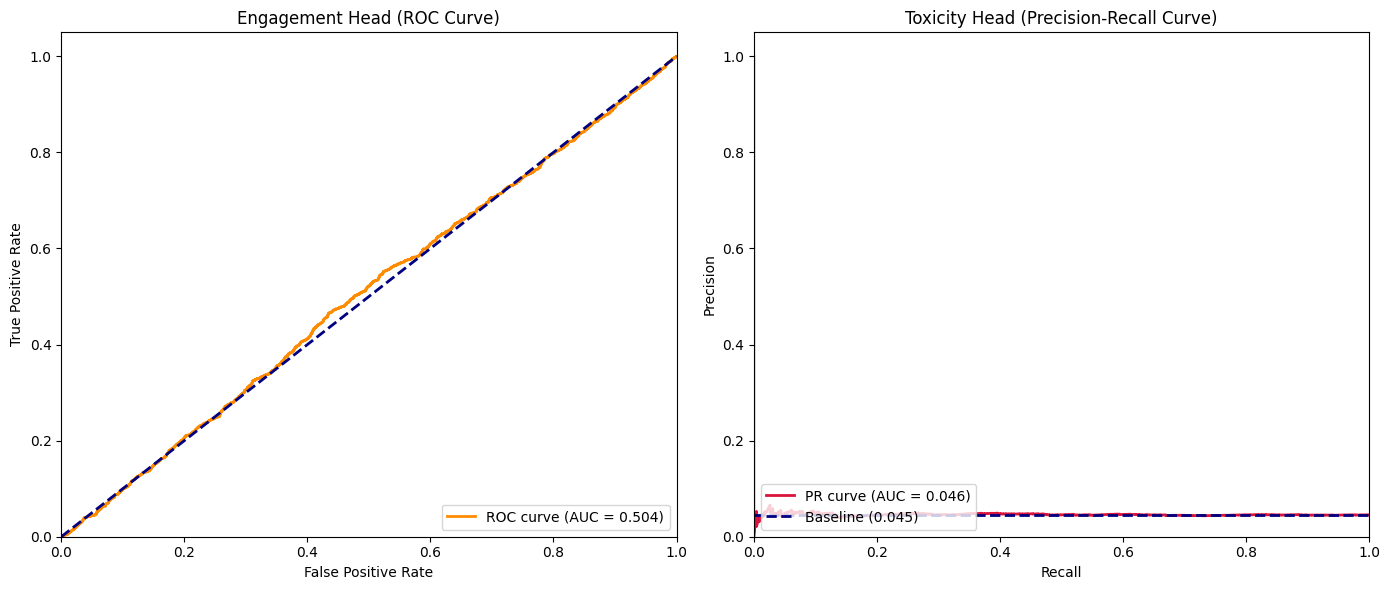

Train Loss: 1.1976, Valid Loss: 1.1848
Saved best model
Epoch 3/5
Batch 125: Loss = 1.1958
Batch 250: Loss = 1.1907
Batch 375: Loss = 1.1888
Batch 500: Loss = 1.1929
Batch 625: Loss = 1.1900
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.4870 | ROC-AUC: 0.5001
Toxicity   -> Accuracy: 0.9546 | ROC-AUC: 0.5000 | PR-AUC: 0.0454\n


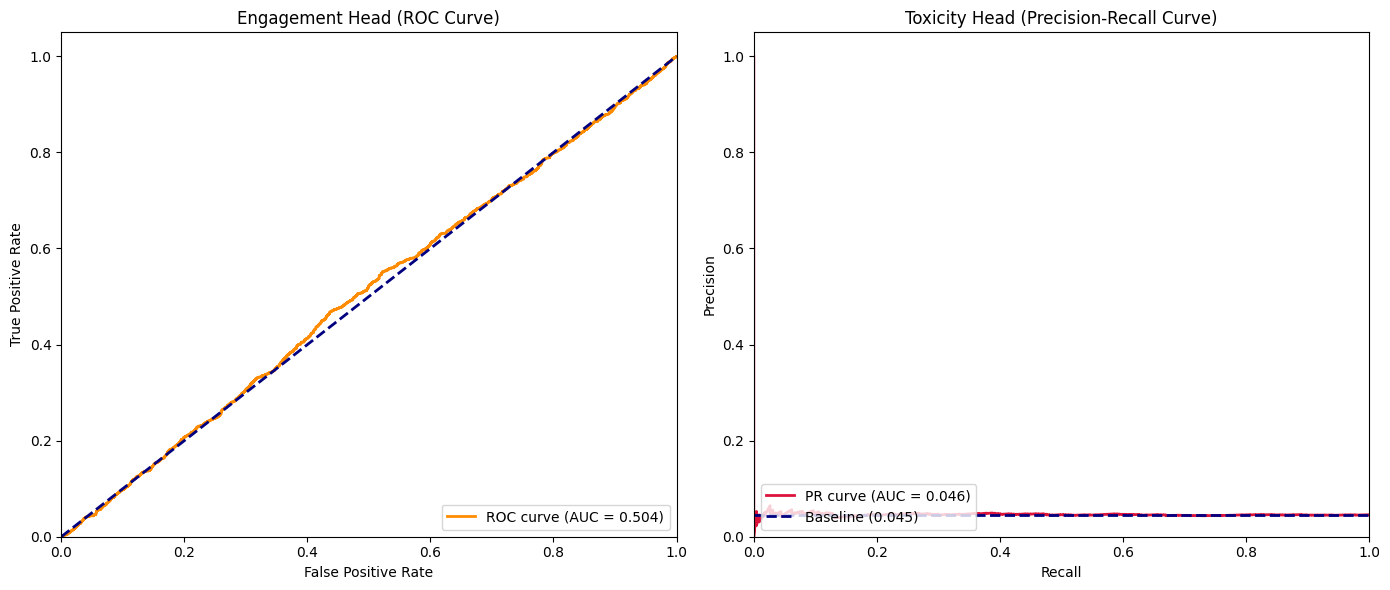

Train Loss: 1.1900, Valid Loss: 1.1766
Saved best model
Epoch 4/5
Batch 125: Loss = 1.1882
Batch 250: Loss = 1.1830
Batch 375: Loss = 1.1812
Batch 500: Loss = 1.1856
Batch 625: Loss = 1.1827
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.4870 | ROC-AUC: 0.5001
Toxicity   -> Accuracy: 0.9546 | ROC-AUC: 0.5000 | PR-AUC: 0.0454\n


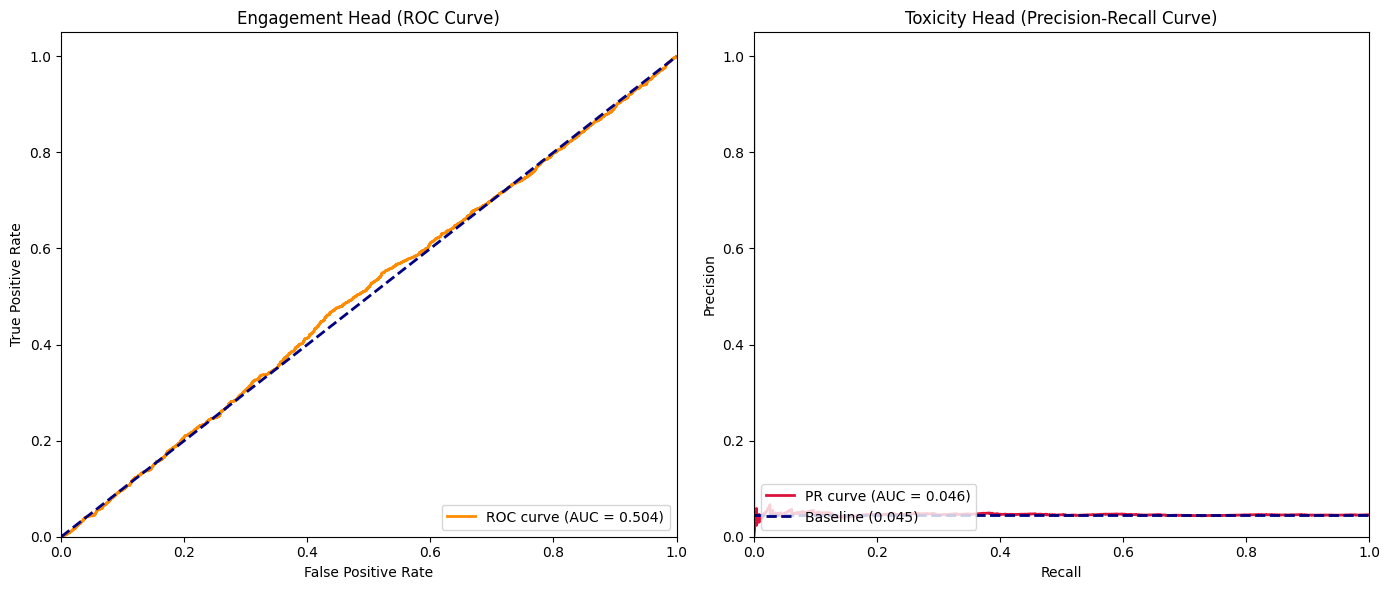

Train Loss: 1.1827, Valid Loss: 1.1686
Saved best model
Epoch 5/5
Batch 125: Loss = 1.1808
Batch 250: Loss = 1.1756
Batch 375: Loss = 1.1738
Batch 500: Loss = 1.1785
Batch 625: Loss = 1.1756
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.4874 | ROC-AUC: 0.5004
Toxicity   -> Accuracy: 0.9546 | ROC-AUC: 0.5000 | PR-AUC: 0.0454\n


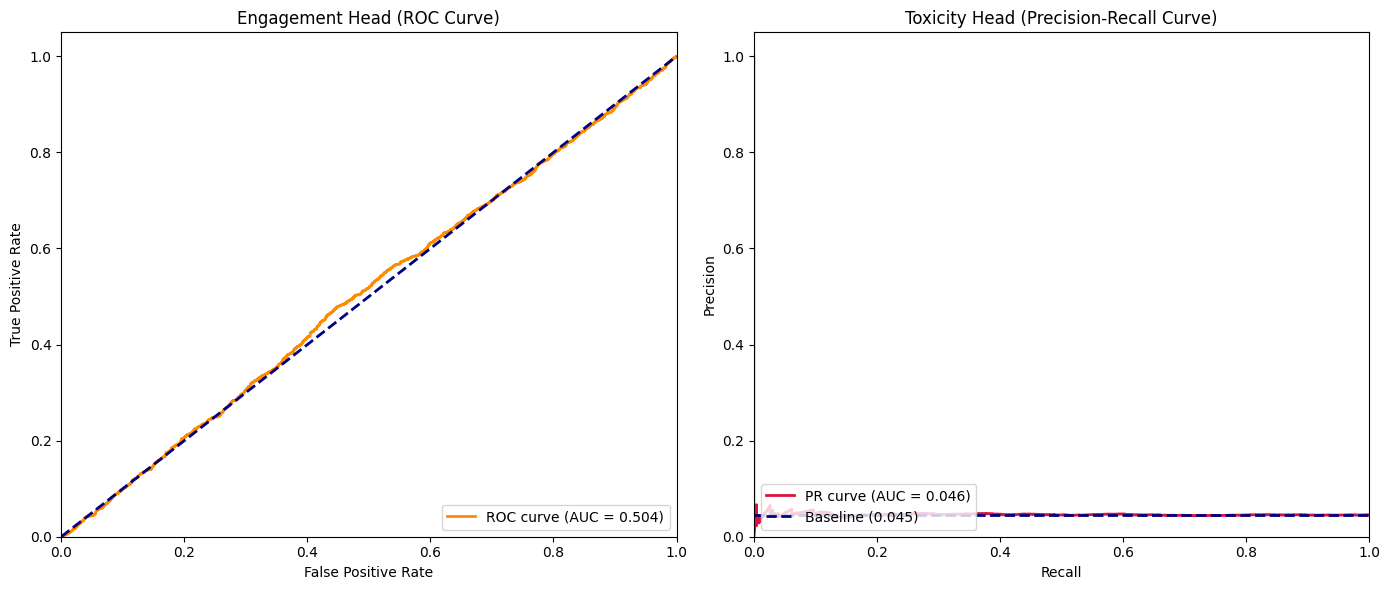

Train Loss: 1.1756, Valid Loss: 1.1609
Saved best model


In [46]:
train(shared_bottom_model, toxicity_train_dataloader, toxicity_valid_dataloader)

### Testing

toxicit_test_data_path = "/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/test.csv"
toxicity_test_data_df = pd.read_csv(toxicit_test_data_path, nrows=10000, low_memory=True, memory_map=True)

toxicity_test_dataset = ToxicityDataset(toxicity_test_data_df, embedding_model, train=False)
toxicity_test_dataloader = DataLoader(toxicity_test_dataset, batch_size=32, num_workers=4, pin_memory=True)

In [54]:
def inference(texts, model, encoder_model, device='cuda'):
    model.eval()
    print(f"--- QUALITATIVE INFERENCE TEST ---")
    print(f"{'INPUT TEXT':<60} | {'ENGAGEMENT PROB'} | {'TOXICITY PROB'}")
    print("-" * 95)

    
    with torch.no_grad():
        for text in texts:
            text_embeddings = encoder_model.encode(text)
            input_tensor = torch.tensor(text_embeddings, dtype=torch.float32).unsqueeze(0).to(device)
    
            eng_out, tox_out = model(input_tensor)
            eng_prob = eng_out.item()
            tox_prob = tox_out.item()
            
            # 4. Truncate text for clean formatting
            text_trunc = (text[:55] + '...') if len(text) > 55 else text
            
            # Print the side-by-side results
            print(f"{text_trunc:<60} | {eng_prob:.4f}          | {tox_prob:.4f}")

In [55]:
test_sentences = [
    "This is a very standard, polite news article about the economy.",
    "You are an absolute idiot, delete your account immediately.",
    "SHOCKING: 10 ways this celebrity ruined their life! (Must Read)",
    "I genuinely loved this movie, the cinematography was beautiful."
]

# Assuming your sentence transformer is named 'embedding_model'
inference(test_sentences, shared_bottom_model, embedding_model)

--- QUALITATIVE INFERENCE TEST ---
INPUT TEXT                                                   | ENGAGEMENT PROB | TOXICITY PROB
-----------------------------------------------------------------------------------------------
This is a very standard, polite news article about the ...   | 0.5041          | 0.3540
You are an absolute idiot, delete your account immediat...   | 0.5061          | 0.3561
SHOCKING: 10 ways this celebrity ruined their life! (Mu...   | 0.5111          | 0.3614
I genuinely loved this movie, the cinematography was be...   | 0.5102          | 0.3620
